In [1]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic


load_dotenv()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [2]:
query = '대손충당금에 대해서 설명해주세요'

In [2]:
from typing import Annotated                # 메타데이터(langgraph가 받을) 다는 라이브러리
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [3]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [4]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

In [5]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [6]:
graph = graph_builder.compile()

In [7]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}

NameError: name 'query' is not defined

In [ ]:
graph.invoke(initial_state)

{'messages': [HumanMessage(content='원천징수되는 기타소득에 관하여 설명하시오', additional_kwargs={}, response_metadata={}, id='7e76a191-af87-412f-b35c-a72ac5c8c354'),
  AIMessage(content='# 원천징수되는 기타소득\n\n## 1. 기타소득의 개념\n기타소득은 이자소득, 배당소득, 사업소득, 근로소득, 연금소득, 퇴직소득, 양도소득, 산림소득에 해당하지 않는 소득으로서 일시적·우발적 성격을 가진 소득을 말합니다.\n\n## 2. 원천징수 대상 기타소득의 종류\n\n### 가. 상금, 현상금, 포상금\n- 경품권, 복권당첨금\n- 각종 경기대회 상금\n- 현상공모 당첨금\n\n### 나. 강연료, 원고료\n- 강의료, 강연료\n- 원고료, 인세\n- 방송출연료\n\n### 다. 인적용역 제공대가\n- 일회성 또는 단발성 용역제공 대가\n- 전문직 자문료\n- 심사료, 감정료\n\n### 라. 기타\n- 사례금\n- 노하우 제공대가\n- 공익신고 포상금\n\n## 3. 원천징수세율\n\n### 가. 일반세율\n- **20%** (지방소득세 2% 별도)\n- 총 **22%** 원천징수\n\n### 나. 특별세율 적용 대상\n- **복권당첨금**: 22% (300만원 초과분)\n- **경품권**: 22% (6만원 초과분)\n- **강연료 등**: 8.8% (건당 50만원 이하)\n\n## 4. 원천징수 방법\n\n### 가. 원천징수 시기\n- 기타소득을 지급하는 때\n- 지급일이 속하는 달의 다음 달 10일까지 신고·납부\n\n### 나. 필요경비 공제\n- **60% 필요경비율** 적용 (일부 소득 제외)\n- 실제 필요경비가 더 큰 경우 실제 필요경비 적용 가능\n\n### 다. 계산 예시\n```\n지급액 100만원인 경우:\n- 필요경비: 100만원 × 60% = 60만원\n- 과세표준: 100만원 - 60만원 = 40만원\n- 원천징수세액: 40

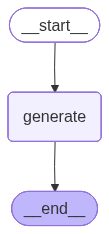

In [8]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## 데이터 전처리

In [9]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
from pyzerox import zerox
import os
import asyncio
from dotenv import load_dotenv

load_dotenv()


model = "claude-sonnet-4-20250514"
custom_system_prompt = None

async def main():
    file_path = "Tax.pdf"
    select_pages = None  # 전체 페이지
    output_dir = "./output_test"
    
    result = await zerox(
        file_path=file_path,
        model=model,
        output_dir=output_dir,
        custom_system_prompt=custom_system_prompt,
        select_pages=select_pages
    )
    return result

# 실행
result = asyncio.run(main())
print(result)

## Retrieve

In [20]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import Docx2txtLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import shutil

# 1. 문서 로드
loader = Docx2txtLoader('./documents/Tax_with_table.docx')
documents = loader.load()

# 2. 텍스트 분할 (청킹)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
splits = text_splitter.split_documents(documents)

In [21]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma


embedding = UpstageEmbeddings(model="solar-embedding-1-large")


# database = Chroma.from_documents(
#     documents=splits,
#     embedding=embedding,
#     collection_name='chroma-tax',
#     persist_directory='./preprocessed-upstage'
# )


database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

In [22]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers.ensemble import EnsembleRetriever


dense_retriever = database.as_retriever(search_kwargs={'k': 4})
bm25_retriever = BM25Retriever.from_documents(splits, k=4)

hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.8, 0.2]  # 논문의 α=0.8
)

In [23]:
query = '원천징수되는 기타소득에 관하여 설명하시오'

hybrid_retriever.invoke(query)

[Document(metadata={'source': './documents/Tax_with_table.docx'}, page_content='표는 연금 수령자의 나이에 따른 세율을 보여주며, 나이가 많을수록 세율이 낮아지는 구조로 되어 있습니다. 70세 미만은 5%, 70세 이상 80세 미만은 4%, 80세 이상은 3%의 세율이 적용됩니다.]\n\n\n나. 삭제<2014. 12. 23.>\n\n다. 사망할 때까지 연금수령하는 대통령령으로 정하는 종신계약에 따라 받는 연금소득에 대해서는 100분의 3\n\n5의3. 제20조의3제1항제2호가목에 따라 퇴직소득을 연금수령하는 연금소득에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 연금 실제 수령연차 및 연금외수령 원천징수세율의 구체적인 내용은 대통령령으로 정한다.\n\n가. 연금 실제 수령연차가 10년 이하인 경우: 연금외수령 원천징수세율의 100분의 70\n\n나. 연금 실제 수령연차가 10년을 초과하고 20년 이하인 경우: 연금외수령 원천징수세율의 100분의 60\n\n다. 연금 실제 수령연차가 20년을 초과하는 경우: 연금외수령 원천징수세율의 100분의 50\n\n6. 기타소득에 대해서는 다음에 규정하는 세율. 다만, 제8호를 적용받는 경우는 제외한다.\n\n가. 제14조제3항제8호라목 및 마목에 해당하는 소득금액이 3억원을 초과하는 경우 그 초과하는 분에 대해서는 100분의 30\n\n나. 제21조제1항제18호 및 제21호에 따른 기타소득에 대해서는 100분의 15\n\n다. 삭제<2014. 12. 23.>\n\n라. 그 밖의 기타소득에 대해서는 100분의 20\n\n7. 퇴직소득에 대해서는 기본세율\n\n8. 대통령령으로 정하는 봉사료에 대해서는 100분의 5\n\n9. 삭제<2024. 12. 31.>\n\n② 제1항에도 불구하고 다음 각 호의 이자소득 및 배당소득에 대해서는 다음 각 호에서 정하는 세율을 원천징수세율로 한다.<개정 2013. 1. 1., 2017. 12. 19., 2018. 12.

## RAG Chain with Node, Edge

In [38]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [39]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langsmith import Client

load_dotenv()


client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [40]:
def retrieve(state: AgentState):
    query  = state['query']         # state의 query를 받아서 
    docs = hybrid_retriever.invoke(query)  # retrieve 하고
    return {'context': docs}        # 그걸 context에 넣어서 toss~

In [41]:
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = prompt | llm
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response}

In [42]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [43]:
from langgraph.graph import START, END

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

In [44]:
graph = graph_builder.compile()

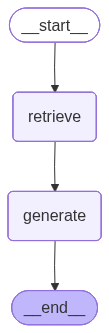

In [45]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

## RAG Chain with Sequence

In [46]:
sequence_graph_builder = StateGraph(AgentState).add_sequence([retrieve, generate])

In [47]:
sequence_graph_builder.add_edge(START, 'retrieve')      # add_sequence에서 함수 이름으로 Node를 만들어놓고 그 사이의 edge도 그어줌
sequence_graph_builder.add_edge('generate', END)

In [48]:
graph = sequence_graph_builder.compile()

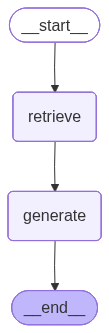

In [49]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
query = '종합소득세 과세표준 구간별 세율은 어떻게 되나요?'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [54]:
response['answer'].content

'종합소득세 과세표준 구간별 세율은 다음과 같습니다. 1,400만원 이하는 6%, 1,400만원 초과 5,000만원 이하는 15%, 5,000만원 초과 8,800만원 이하는 24%, 8,800만원 초과 1억5천만원 이하는 35%, 1억5천만원 초과 3억원 이하는 38%, 3억원 초과 5억원 이하는 40%, 5억원 초과 10억원 이하는 42%, 10억원 초과는 45%의 누진세율이 적용됩니다. 이는 소득이 높아질수록 더 높은 세율이 적용되는 누진세 체계입니다.'

In [55]:
query = '직장인이 부업으로 프리랜서 수입이 생기면 세금을 어떻게 내야 하나요?'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [56]:
response['answer'].content

'제공된 문서에는 직장인이 부업으로 프리랜서 수입이 생겼을 때의 구체적인 세금 납부 방법에 대한 내용이 포함되어 있지 않습니다. 문서는 주로 원천징수, 과세자료 제출, 가산세 등에 관한 조항들을 다루고 있습니다. 정확한 답변을 위해서는 종합소득세 신고 및 부업소득 과세에 관한 더 구체적인 세법 조항이 필요합니다.'